<a href="https://colab.research.google.com/github/VladLoPG/neural_networks/blob/main/%D0%9B%D0%BE%D0%B1%D0%B0%D0%BD%D0%BE%D0%B2_hw2_word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Разбор архитектуры Word2Vec: CBOW (Continuous Bag-of-Words) и Skip-Gram с Negative Sampling

- Загрузка и предобработка корпуса новостей
- Обучение моделей
- Визуализация
- Анализ эмбеддингов

---
# Домашнее задание (Word2Vec Advanced)

**Задание состоит из двух частей:**

1.  **Практическая часть: Обучение и анализ.**
    *   Обучите модели CBOW и Skip-Gram с Negative Sampling на предоставленном корпусе новостей, используя код из ноутбука.
    *   Для одной из моделей (на ваш выбор) проведите визуализацию эмбеддингов (как в п. 7.1) для 15-20 слов, относящихся к разным тематикам (например, политика, спорт, медицина, культура).
    *   **Проанализируйте** получившийся график: образуют ли слова из одной темы кластеры? Есть ли слова, которые, на ваш взгляд, находятся не в своем кластере? Почему это могло произойти?

2.  **Аналитическая часть: Эксперимент с гиперпараметрами.**
    *   Выберите одну из моделей (например, Skip-Gram) и один набор тестовых слов (например, `['коронавирус', 'инфекция', 'болезнь', 'вакцина']`).
    *   Проведите небольшое исследование, как изменение следующих гиперпараметров влияет на качество получаемых эмбеддингов (используйте косинусное сходство или аналогии как метрику):
        *   **Размер окна (window size):** Попробуйте значения 1, 3, 5.
        *   **Размерность эмбеддинга (embedding size):** Попробуйте значения 50, 100, 200.
    *   **Опишите** свои наблюдения. Какой размер окна лучше подходит для поиска тематически близких слов, а какой — для синтаксически близких? Влияет ли размерность на скорость обучения и на качество?

**Формат сдачи:**
Оформите отчет (в формате `.ipynb` или `.pdf`), который включает:
*   Краткое описание проделанной работы.
*   Графики из п.1 и ваш анализ к ним.
*   Таблицу или графики, иллюстрирующие влияние гиперпараметров из п.2, и ваши выводы.

## Практическая часть
Подготовительный код: загрузки, разделение выборки, подготовка данных

In [1]:
!pip install colorama natasha -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 121.8 MB/s eta 0:00:00


In [66]:
from colorama import Fore, Style
import json
import random

from natasha import NewsMorphTagger, NewsEmbedding, Doc, Segmenter

import re
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD, Adam
from torch.utils.data import DataLoader, Dataset
import copy

from sklearn.decomposition import TruncatedSVD, PCA
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.metrics.pairwise import cosine_similarity

# Для корректного отображения графиков в Colab
%matplotlib inline

# Определяем устройство один раз глобально
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{Fore.GREEN}Используется устройство: {device}{Style.RESET_ALL}")

Используется устройство: cuda


In [3]:
# загружаем корпус
!wget -q --show-progress https://raw.githubusercontent.com/vifirsanova/W2V/main/corpus.json

with open('corpus.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"{Fore.GREEN}Корпус загружен. Пример записи:{Style.RESET_ALL}")
data['data'][0]

corpus.json         100%[===================>]  87.84M   226MB/s    in 0.4s    
Корпус загружен. Пример записи:


{'link': 'https://www.mk.ru/social/2020/03/31/minobrnauki-pereneslo-vstupitelnye-ekzameny-v-vuzy-izza-koronavirusa.html',
 'title': 'Минобрнауки решило перенести вступительные экзамены в вузы из-за коронавируса',
 'date': '31.03.2020',
 'time': '09:11',
 'rubric': 'Общество',
 'text': '\nВ Минобрнауки РФ приняли решение перенести даты вступительных экзаменов в вузы из-за коронавируса, заявил глава ведомства Валерий Фальков в интервью «Россия 24».\nОн отметил, что в этом году число бюджетных мест было увеличено на 34 тысячи. Сейчас начался экономический спад, но менять стратегию в министерстве не намерены.\nРешение об увеличении бюджетных мест в вузах связано с ростом числа выпускников школ. Будет увеличено число мест на педагогическом и медицинском направлениях. Большой запрос на бюджетные места у регионов, подчеркнул Фальков.\nРанее власти перенесли даты ЕГЭ и ОГЭ.\nЧитайте также:\xa0Скворцова похвалила российский препарат от коронавируса\n\xa0\n\n'}

In [4]:
# извлекаем тексты и перемешиваем
full_dataset = [item['text'] for item in data['data']]
random.shuffle(full_dataset)

# разделяем на train/val -> sklearn test_train_split
split = int(0.8 * len(full_dataset))
train_texts = full_dataset[:split]
val_texts = full_dataset[split:]

print(f"{Fore.GREEN}Обучающая выборка: {len(train_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}Проверочная выборка: {len(val_texts)} документов{Style.RESET_ALL}")
print(f"{Fore.GREEN}\nПример текста:{Style.RESET_ALL}\n{train_texts[0][:500]}...")

Обучающая выборка: 36736 документов
Проверочная выборка: 9184 документов

Пример текста:

Решение Чехии выслать 18 дипломатов серьезно повредит двусторонним отношениям с Россией, заявил председатель комитета Госдумы по международным делам Леонид Слуцкий.
«Высылка 18 сотрудников дипмиссии - серьезный удар по двусторонним отношениям с Россией», - отметил он.
По словам главы комитета, основания для высылки дипломатов «не выдерживают критики», равно как и «отсылки к событиям 2014 года». Слуцкий выразил уверенность, что «реальных причин для такого шага не было».
Кроме того, напомнил он, ...


In [5]:
# создаем объекты Doc
train_docs = [Doc(text) for text in train_texts[:100]] # Для демо возьмем часть
val_docs = [Doc(text) for text in val_texts[:20]]

# сегментируем на токены и предложения
segmenter = Segmenter()
for doc in train_docs + val_docs:
    doc.segment(segmenter)
print(doc)
# тэггируем части речи
morph_tagger = NewsMorphTagger(NewsEmbedding())
for doc in train_docs + val_docs:
    doc.tag_morph(morph_tagger)

print(f"{Fore.GREEN}Пример размеченного токена:{Style.RESET_ALL}")
tok = val_docs[0].tokens[0]
print(f"Слово: {tok.text}, PoS: {tok.pos}, Морфология: {tok.feats}")

Doc(text='\nМЧС сообщило о поисках группы туристов из трех ..., tokens=[...], sents=[...])
Пример размеченного токена:
Слово: Президент, PoS: NOUN, Морфология: {'Animacy': 'Anim', 'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Sing'}


In [6]:
# сохраним разметку для будущих задач
def build_tag_dict(docs):
    tag_dict = {}
    for doc in docs:
        for tok in doc.tokens:
            if tok.text not in tag_dict:
                tag_dict[tok.text] = (tok.pos, tok.feats)
    return tag_dict

train_tag_dict = build_tag_dict(train_docs)
val_tag_dict = build_tag_dict(val_docs)

print(f"{Fore.GREEN}Размер словаря тегов: {len(train_tag_dict)}{Style.RESET_ALL}")

Размер словаря тегов: 4336


In [7]:
# Загружаем стоп-слова
!wget -q https://raw.githubusercontent.com/vifirsanova/W2V/main/swl.txt
with open('swl.txt', 'r', encoding='utf-8') as f:
    stop_words = set([line.strip() for line in f])

print(f"{Fore.GREEN}Загружено {len(stop_words)} стоп-слов. Пример: {list(stop_words)[:5]}{Style.RESET_ALL}")

# Токенизатор
def tokenize(text):
    """Разбивает текст на токены (слова и цифры), приводит к нижнему регистру."""
    return re.findall(r'[\w\d]+', text.lower())

train_tokenized = [tokenize(text) for text in train_texts]
val_tokenized = [tokenize(text) for text in val_texts]

print(f"{Fore.GREEN}Пример токенизации:{Style.RESET_ALL}")
print(' '.join(train_tokenized[0][:15]))

Загружено 925 стоп-слов. Пример: ['', 'кабы', 'конечно', 'неужели', 'именно']
Пример токенизации:
решение чехии выслать 18 дипломатов серьезно повредит двусторонним отношениям с россией заявил председатель комитета госдумы


In [8]:
def build_vocab(tokenized_corpus, stop_words, pad_word='<PAD>'):
    """
    Строит словарь на основе токенизированного корпуса.
    Возвращает:
        word2id: соответствие слово -> индекс
        word_doc_freq: частотность слов в корпусе (количество документов, где слово встретилось)
    """
    doc_freq = defaultdict(int)
    for text in tokenized_corpus:
        # считаем по документо-частоте, а не по частоте вхождений
        #print(text)
        for word in set(text):
            if word not in stop_words:
                doc_freq[word] += 1
                #print(doc_freq)
            #else:
                #print(word, 'в списке стоп-слов!!')

    # удаляем редкие слова (встретились только в 1 документе)
    doc_freq = {w: cnt for w, cnt in doc_freq.items() if cnt > 1}

    # сортируем по убыванию частоты
    sorted_vocab = sorted(doc_freq.items(), key=lambda x: -x[1])
    words = [pad_word] + [w for w, _ in sorted_vocab]

    word2id = {w: i for i, w in enumerate(words)}
    word_doc_freq = np.array([0] + [cnt for _, cnt in sorted_vocab], dtype='float32')
    # нормируем, чтобы получить вероятность встретить слово в случайном документе
    word_doc_freq /= len(tokenized_corpus)

    return word2id, word_doc_freq

word2id, word_doc_freq = build_vocab(train_tokenized, stop_words)

vocab_size = len(word2id)
print(f"{Fore.GREEN}Размер словаря: {vocab_size}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Первые 10 слов словаря:{Style.RESET_ALL}")
list(word2id.items())[:10]

Размер словаря: 85865
Первые 10 слов словаря:


[('<PAD>', 0),
 ('этом', 1),
 ('а', 2),
 ('россии', 3),
 ('ранее', 4),
 ('заявил', 5),
 ('словам', 6),
 ('время', 7),
 ('будет', 8),
 ('коронавируса', 9)]

In [9]:
def texts_to_ids(tokenized_corpus, word2id):
    """Заменяет слова на их индексы. Незнакомые слова игнорируются."""
    return [[word2id[token] for token in text if token in word2id] for text in tokenized_corpus]

train_ids = texts_to_ids(train_tokenized, word2id)
val_ids = texts_to_ids(val_tokenized, word2id)

print(f"{Fore.GREEN}Исходный текст:{Style.RESET_ALL} {train_tokenized[0][:5]}")
print(f"{Fore.GREEN}Числовые ID:{Style.RESET_ALL} {train_ids[0][:5]}")
print(f"{Fore.GREEN}Обратно по словарю:{Style.RESET_ALL} {[list(word2id.keys())[i] for i in train_ids[0][:5]]}")

Исходный текст: ['решение', 'чехии', 'выслать', '18', 'дипломатов']
Числовые ID: [155, 1825, 9076, 280, 2217]
Обратно по словарю: ['решение', 'чехии', 'выслать', '18', 'дипломатов']


## Обучение CBOW

In [10]:
# Гиперпараметры
CONTEXT_SIZE = 2  # Количество слов С КАЖДОЙ стороны от центрального. Всего контекст = 2*CONTEXT_SIZE
EMBEDDING_DIM = 100
EPOCHS_CBOW = 2  # Уменьшили с 5 до 2

class CBOWDataset(Dataset):
    def __init__(self, data_ids, context_size):
        """
        data_ids: список текстов, где каждый текст - список ID токенов.
        context_size: сколько слов брать слева и справа.
        """
        self.pairs = []  # ( [id_контекстных_слов], id_целевого_слова )
        for text in data_ids:
            if len(text) < 2*context_size + 1:
                continue
            for i in range(context_size, len(text) - context_size):
                context = text[i-context_size:i] + text[i+1:i+context_size+1]
                target = text[i]
                self.pairs.append( (context, target) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        context, target = self.pairs[idx]
        return torch.tensor(context, dtype=torch.long), torch.tensor(target, dtype=torch.long)

# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

print(f"{Fore.GREEN}Количество обучающих примеров для CBOW: {len(cbow_train_dataset)}{Style.RESET_ALL}")
print(f"{Fore.GREEN}Пример: контекст {cbow_train_dataset[0][0].tolist()} -> цель {cbow_train_dataset[0][1].item()}{Style.RESET_ALL}")

Количество обучающих примеров для CBOW: 3526276
Пример: контекст [155, 1825, 280, 2217] -> цель 9076


In [11]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # Простой линейный слой для предсказания слова по среднему контекстному вектору
        self.linear = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_words):
        # context_words: (batch_size, 2*CONTEXT_SIZE)
        embeds = self.embeddings(context_words)  # (batch_size, 2*CONTEXT_SIZE, emb_dim)
        # Усредняем эмбеддинги контекстных слов
        averaged = torch.mean(embeds, dim=1)    # (batch_size, emb_dim)
        out = self.linear(averaged)             # (batch_size, vocab_size)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs

    def get_word_vector(self, word_idx):
        """Возвращает вектор для заданного индекса слова."""
        return self.embeddings(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [12]:
# Функция для обучения с поддержкой CUDA и ограничением батчей
def train_cbow(model, train_loader, val_loader, epochs, lr=0.001, device='cpu', max_batches=500):
    model.to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, (context, target) in enumerate(train_loader):
            if i >= max_batches:  # Ограничиваем количество батчей
                break

            context, target = context.to(device), target.to(device)

            optimizer.zero_grad()
            log_probs = model(context)
            loss = criterion(log_probs, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        # Валидация (тоже ограничиваем)
        model.eval()
        val_loss = 0
        val_count = 0
        with torch.no_grad():
            for i, (context, target) in enumerate(val_loader):
                if i >= max_batches // 2:  # Меньше батчей для валидации
                    break
                context, target = context.to(device), target.to(device)
                log_probs = model(context)
                loss = criterion(log_probs, target)
                val_loss += loss.item()
                val_count += 1

        print(f"Epoch {epoch+1}, Train Loss: {total_loss/batch_count:.4f}, Val Loss: {val_loss/val_count:.4f}")

    return model

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 8.1023, Val Loss: 5.8522
Epoch 2, Train Loss: 6.3568, Val Loss: 5.4930


## Skip Gram

In [13]:
# Гиперпараметры для Skip-Gram
WINDOW_SIZE = 2          # Размер окна (с каждой стороны)
NEG_SAMPLES = 5          # Количество негативных примеров на один позитивный
EMB_DIM_SG = 100
EPOCHS_SG = 1  # Уменьшили до 1 эпохи

class SkipGramDataset(Dataset):
    def __init__(self, data_ids, window_size, neg_samples, vocab_size):
        self.data_ids = data_ids
        self.window_size = window_size
        self.neg_samples = neg_samples
        self.vocab_size = vocab_size
        self.pairs = []  # список (центр, контекст)
        for text in data_ids:
            text_len = len(text)
            for i, target in enumerate(text):
                # Определяем динамическое окно
                start = max(0, i - window_size)
                end = min(text_len, i + window_size + 1)
                for j in range(start, end):
                    if j == i: continue
                    self.pairs.append( (target, text[j]) )

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, pos_context = self.pairs[idx]
        # Генерируем негативные примеры
        neg_contexts = torch.randint(1, self.vocab_size, (self.neg_samples,))
        return (torch.tensor(center, dtype=torch.long),
                torch.tensor(pos_context, dtype=torch.long),
                neg_contexts)

sg_dataset = SkipGramDataset(train_ids, WINDOW_SIZE, NEG_SAMPLES, vocab_size)
print(f"{Fore.GREEN}Датасет для Skip-Gram: {len(sg_dataset)} пар{Style.RESET_ALL}")

Датасет для Skip-Gram: 14472384 пар


In [14]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        self.center_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.context_emb = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Инициализация (Xavier)
        nn.init.xavier_uniform_(self.center_emb.weight)
        nn.init.xavier_uniform_(self.context_emb.weight)
        # Обнуляем паддинг
        self.center_emb.weight.data[0] = 0
        self.context_emb.weight.data[0] = 0

    def forward(self, center, pos_context, neg_contexts):
        """
        center: (batch_size,)
        pos_context: (batch_size,)
        neg_contexts: (batch_size, neg_samples)
        """
        center_vec = self.center_emb(center)  # (batch, emb_dim)
        pos_vec = self.context_emb(pos_context)  # (batch, emb_dim)
        neg_vecs = self.context_emb(neg_contexts)  # (batch, neg_samples, emb_dim)

        # Положительное сходство (чем больше, тем лучше)
        pos_score = torch.sum(center_vec * pos_vec, dim=1)  # (batch,)
        pos_loss = -F.logsigmoid(pos_score).mean()

        # Отрицательное сходство (чем меньше, тем лучше)
        neg_score = torch.bmm(neg_vecs, center_vec.unsqueeze(2)).squeeze()  # (batch, neg_samples)
        neg_loss = -F.logsigmoid(-neg_score).mean()

        return pos_loss + neg_loss

    def get_center_vector(self, word_idx):
        return self.center_emb(torch.tensor([word_idx])).detach().cpu().numpy()[0]

In [15]:
def train_skipgram(model, dataset, epochs, batch_size=512, lr=0.01, device='cpu', max_batches=300):
    model.to(device)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                       collate_fn=lambda x: list(zip(*x)), num_workers=2, pin_memory=True)
    optimizer = Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_count = 0

        for i, batch in enumerate(loader):
            if i >= max_batches:
                break

            centers, pos_contexts, neg_contexts = batch
            centers = torch.stack(centers).to(device)
            pos_contexts = torch.stack(pos_contexts).to(device)
            neg_contexts = torch.stack(neg_contexts).to(device)

            optimizer.zero_grad()
            loss = model(centers, pos_contexts, neg_contexts)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batch_count += 1

        print(f"Epoch {epoch+1}, Loss: {total_loss/batch_count:.4f}")

    return model

sg_model = SkipGramNegSampling(vocab_size, EMB_DIM_SG)
# Обучаем с ограничением батчей
sg_model = train_skipgram(sg_model, sg_dataset, epochs=EPOCHS_SG, batch_size=512,
                          device=device, max_batches=300)

Epoch 1, Loss: 0.9162


In [17]:
class WordEmbeddings:
    def __init__(self, embedding_matrix, word2id):
        """
        embedding_matrix: numpy array, shape (vocab_size, emb_dim)
        """
        self.embeddings = embedding_matrix
        # Нормируем для косинусного сходства
        self.norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self.norms[self.norms == 0] = 1  # защита от деления на 0 для PAD
        self.normed_emb = self.embeddings / self.norms

        self.word2id = word2id
        self.id2word = {v: k for k, v in word2id.items()}

    def get_vector(self, word):
        if word not in self.word2id:
            raise KeyError(f"Слово '{word}' не найдено в словаре")
        return self.embeddings[self.word2id[word]]

    def most_similar(self, word, k=10):
        """Возвращает k самых близких слов по косинусной мере."""
        vec = self.get_vector(word)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        # Сортируем по убыванию и берем топ-k, исключая само слово
        best_ids = np.argsort(scores)[::-1]
        best_ids = [idx for idx in best_ids if idx != self.word2id[word]][:k]
        return [(self.id2word[idx], scores[idx]) for idx in best_ids]

    def analogy(self, word_a, word_b, word_c, k=5):
        """Решает пропорцию: word_a относится к word_b так же, как word_c относится к ?."""
        # vec_a - vec_b + vec_c
        vec = self.get_vector(word_a) - self.get_vector(word_b) + self.get_vector(word_c)
        vec_normed = vec / (np.linalg.norm(vec) + 1e-8)
        scores = self.normed_emb @ vec_normed
        best_ids = np.argsort(scores)[::-1]
        # Исключаем исходные слова из результата
        exclude_ids = {self.word2id.get(w, -1) for w in [word_a, word_b, word_c]}
        result = []
        for idx in best_ids:
            if idx not in exclude_ids:
                result.append((self.id2word[idx], scores[idx]))
            if len(result) == k:
                break
        return result

# Создаем объекты для наших моделей
cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)
sg_emb = WordEmbeddings(sg_model.center_emb.weight.detach().cpu().numpy(), word2id)

Визуализация CBOW эмбеддингов:


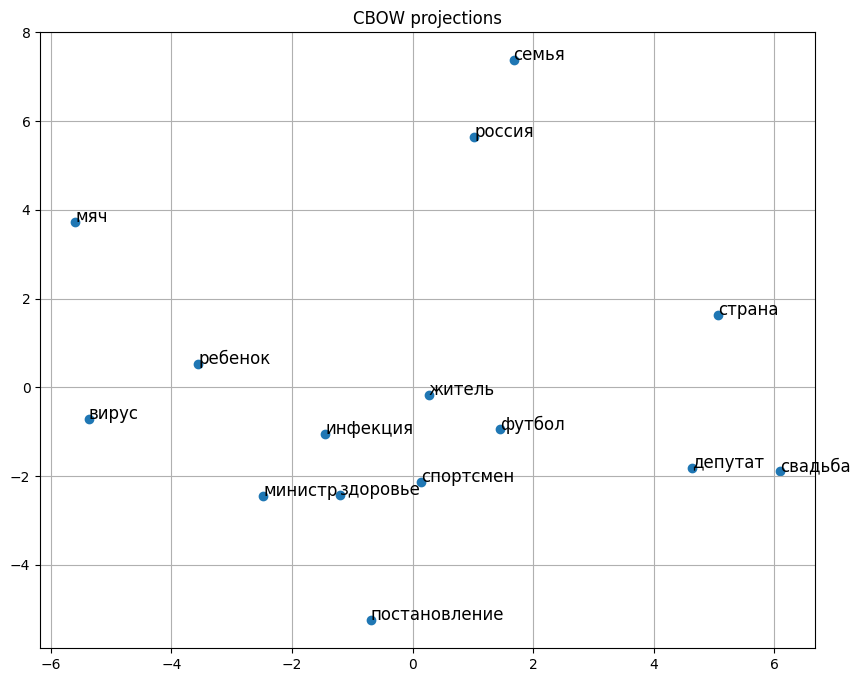

Визуализация Skip-Gram эмбеддингов:


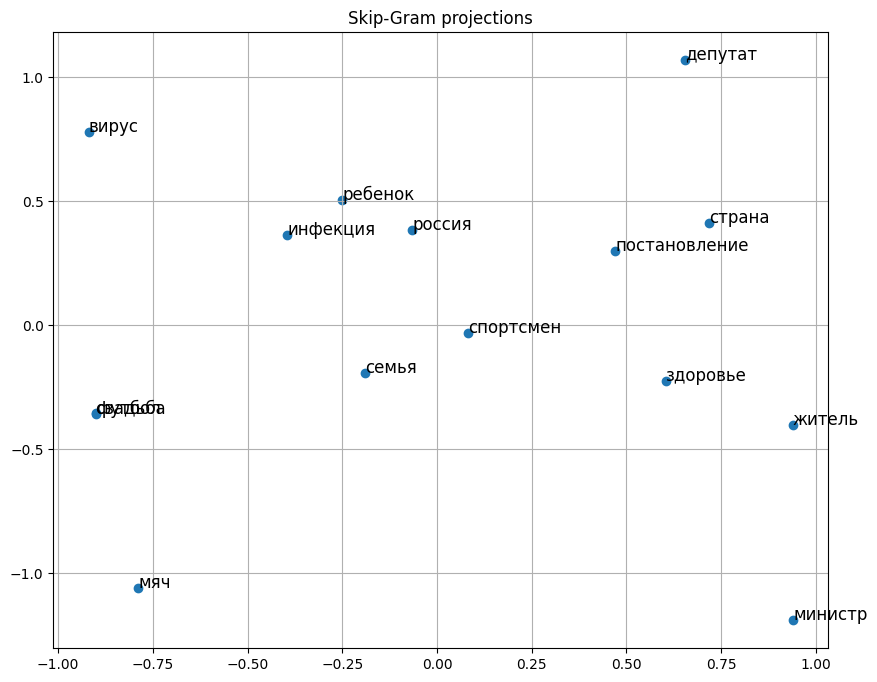

In [20]:
words_to_plot = ['футбол', 'мяч', 'спортсмен',
                 'министр', 'депутат', 'постановление',
                 'инфекция', 'вирус', 'здоровье',
                 'ребенок', 'семья', 'свадьба',
                 'житель', 'россия', 'страна']

def plot_embeddings(embeddings_obj, words, title):
    vectors = []
    valid_words = []
    for w in words:
        if w in embeddings_obj.word2id:
            vectors.append(embeddings_obj.get_vector(w))
            valid_words.append(w)

    if len(vectors) < 2:
        print("Недостаточно слов для визуализации")
        return

    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(np.array(vectors))

    plt.figure(figsize=(10, 8))
    plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1])
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vecs_2d[i, 0], vecs_2d[i, 1]), fontsize=12)
    plt.title(title)
    plt.grid(True)
    plt.show()

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

print(f"{Fore.RED}Визуализация Skip-Gram эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(sg_emb, words_to_plot, "Skip-Gram projections")

## Анализ визуализации

Получилось не очень. Есть более-менее информативный кластер "страна+инфекция+семья+министр+здоровье", может быть связано с новостями о коронавирусе и коллокациями, но остальное все разбросано по плоскости без значимой связи. Думаю, связано со слабым обучением модели и сложностью текстов

## Аналитическая часть для CBOW

In [94]:
CONTEXT_SIZE = 1
EMBEDDING_DIM = 50
EPOCHS_CBOW = 3

In [95]:
# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 8.8317, Val Loss: 6.3497
Epoch 2, Train Loss: 6.7153, Val Loss: 5.8074
Epoch 3, Train Loss: 6.3734, Val Loss: 5.5839


Попарное косинусное сходство:

   министр — правительство: -0.2479
   министр — закон     : 0.1750
   министр — власть    : 0.1861
правительство — закон     : 0.0443
правительство — власть    : 0.0474
     закон — власть    : 0.1714
Визуализация CBOW эмбеддингов:


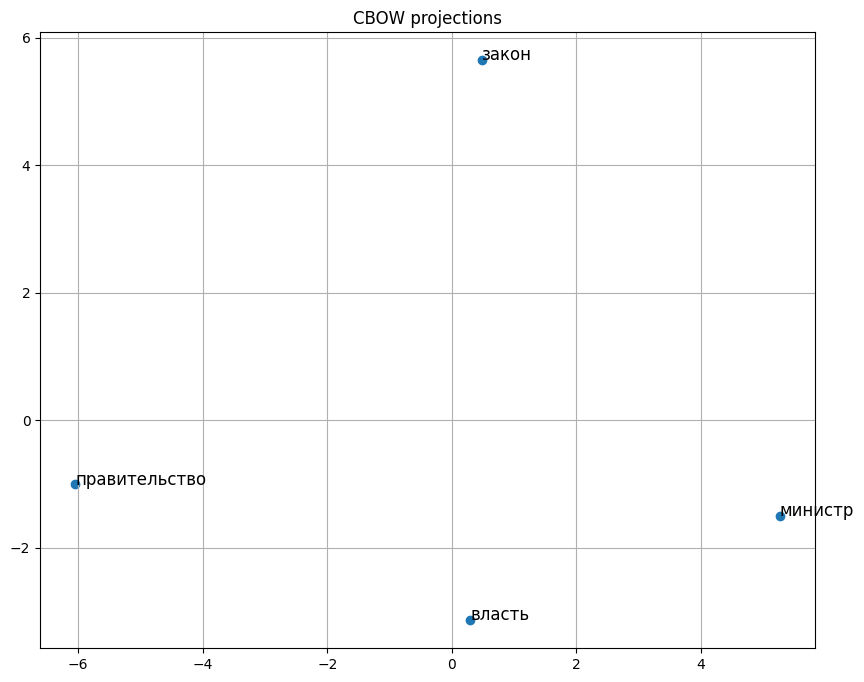

In [96]:
words_to_plot = ["министр", "правительство", "закон", "власть"]

cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)

print("Попарное косинусное сходство:\n")

for w1, w2 in combinations(words_to_plot, 2):
    if w1 in cbow_emb.word2id and w2 in cbow_emb.word2id:
        id1 = cbow_emb.word2id[w1]
        id2 = cbow_emb.word2id[w2]

        sim = np.dot(cbow_emb.normed_emb[id1], cbow_emb.normed_emb[id2])
        print(f"{w1:>10} — {w2:<10}: {sim:.4f}")
    else:
        print(f"{w1} или {w2} нет в словаре")

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

а теперь модель связала здоровье и футбол, хотя вряд ли они употребляются в похожих контекстах

In [97]:
CONTEXT_SIZE = 1
EMBEDDING_DIM = 100
EPOCHS_CBOW = 3

In [98]:
# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 8.1182, Val Loss: 5.9781
Epoch 2, Train Loss: 6.4806, Val Loss: 5.5864
Epoch 3, Train Loss: 6.1350, Val Loss: 5.3900


Попарное косинусное сходство:

   министр — правительство: 0.1784
   министр — закон     : 0.1048
   министр — власть    : 0.0839
правительство — закон     : -0.0631
правительство — власть    : 0.0826
     закон — власть    : -0.0973
Визуализация CBOW эмбеддингов:


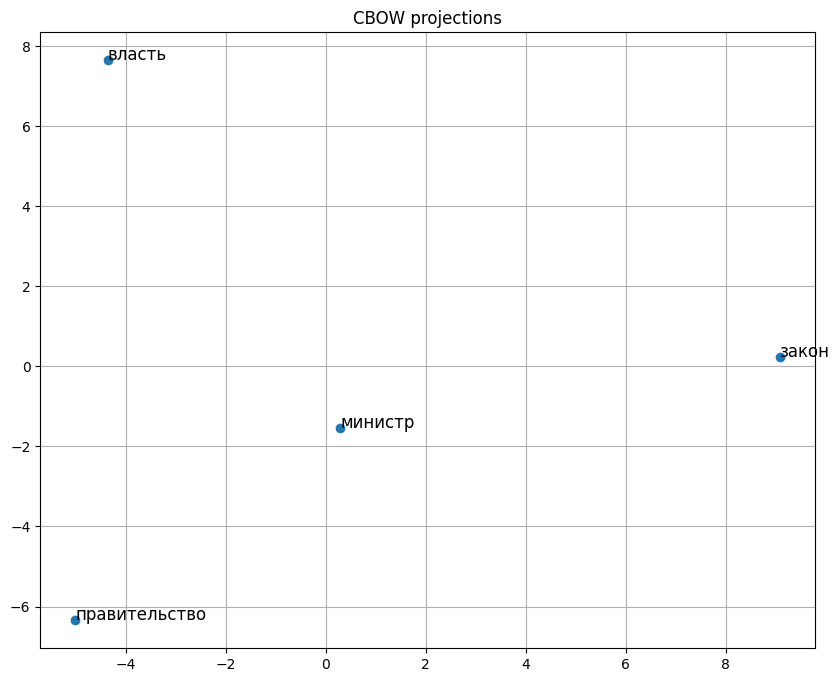

In [99]:
words_to_plot = ["министр", "правительство", "закон", "власть"]

cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)

print("Попарное косинусное сходство:\n")

for w1, w2 in combinations(words_to_plot, 2):
    if w1 in cbow_emb.word2id and w2 in cbow_emb.word2id:
        id1 = cbow_emb.word2id[w1]
        id2 = cbow_emb.word2id[w2]

        sim = np.dot(cbow_emb.normed_emb[id1], cbow_emb.normed_emb[id2])
        print(f"{w1:>10} — {w2:<10}: {sim:.4f}")
    else:
        print(f"{w1} или {w2} нет в словаре")

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

а теперь модель связала здоровье и футбол, хотя вряд ли они употребляются в похожих контекстах

In [102]:
CONTEXT_SIZE = 1
EMBEDDING_DIM = 200
EPOCHS_CBOW = 3

In [103]:
# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 7.4662, Val Loss: 5.7446
Epoch 2, Train Loss: 6.2306, Val Loss: 5.3911
Epoch 3, Train Loss: 5.9129, Val Loss: 5.2054


Попарное косинусное сходство:

   министр — правительство: 0.0030
   министр — закон     : 0.0181
   министр — власть    : 0.0139
правительство — закон     : 0.0404
правительство — власть    : -0.1166
     закон — власть    : -0.0973
Визуализация CBOW эмбеддингов:


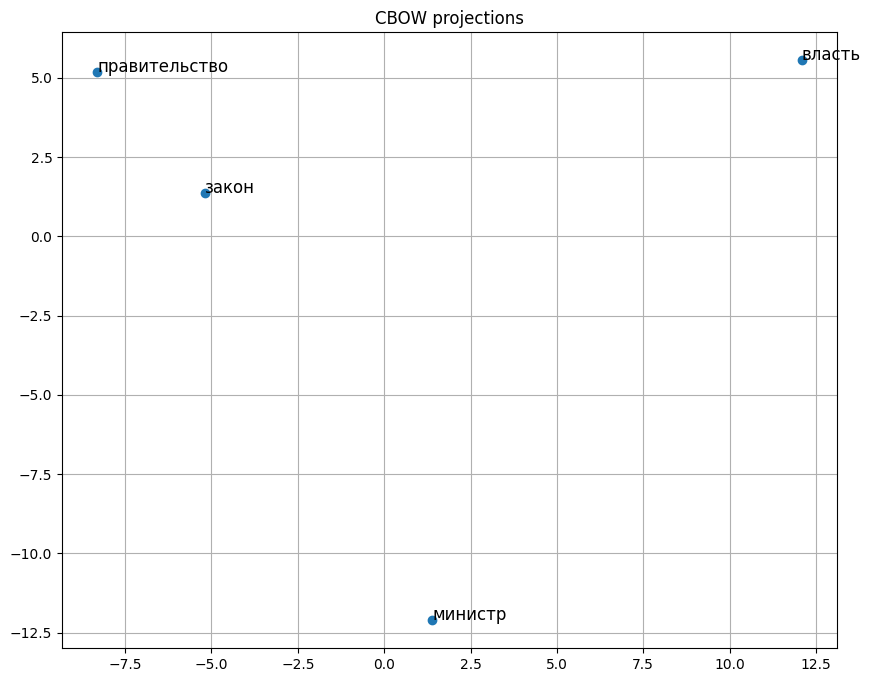

In [104]:
words_to_plot = ["министр", "правительство", "закон", "власть"]

cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)

print("Попарное косинусное сходство:\n")

for w1, w2 in combinations(words_to_plot, 2):
    if w1 in cbow_emb.word2id and w2 in cbow_emb.word2id:
        id1 = cbow_emb.word2id[w1]
        id2 = cbow_emb.word2id[w2]

        sim = np.dot(cbow_emb.normed_emb[id1], cbow_emb.normed_emb[id2])
        print(f"{w1:>10} — {w2:<10}: {sim:.4f}")
    else:
        print(f"{w1} или {w2} нет в словаре")

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

Просто увеличение эпох не повлияло на результат, все еще плохо. Но можем оставить 5 эпох на будущее, тк ошибка снижается, а обучение недолгое пока что

In [105]:
CONTEXT_SIZE = 3
EMBEDDING_DIM = 100
EPOCHS_CBOW = 3

In [106]:
# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 8.1549, Val Loss: 5.8756
Epoch 2, Train Loss: 6.2975, Val Loss: 5.4662
Epoch 3, Train Loss: 6.0864, Val Loss: 5.3164


Попарное косинусное сходство:

   министр — правительство: 0.0269
   министр — закон     : 0.0918
   министр — власть    : 0.0818
правительство — закон     : -0.0941
правительство — власть    : 0.1748
     закон — власть    : -0.0570
Визуализация CBOW эмбеддингов:


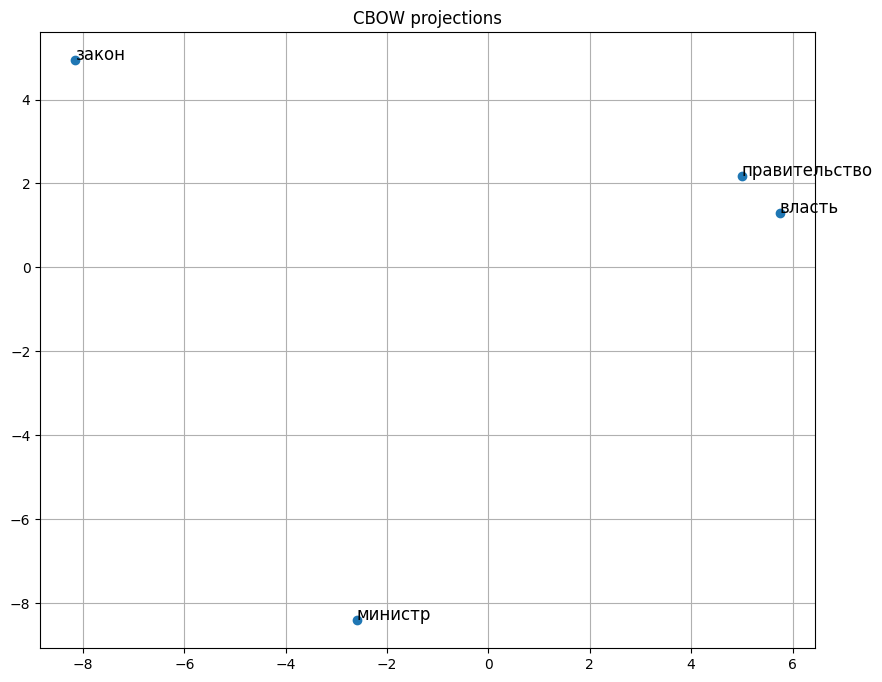

In [107]:
words_to_plot = ["министр", "правительство", "закон", "власть"]

cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)

print("Попарное косинусное сходство:\n")

for w1, w2 in combinations(words_to_plot, 2):
    if w1 in cbow_emb.word2id and w2 in cbow_emb.word2id:
        id1 = cbow_emb.word2id[w1]
        id2 = cbow_emb.word2id[w2]

        sim = np.dot(cbow_emb.normed_emb[id1], cbow_emb.normed_emb[id2])
        print(f"{w1:>10} — {w2:<10}: {sim:.4f}")
    else:
        print(f"{w1} или {w2} нет в словаре")

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

In [108]:
CONTEXT_SIZE = 5
EMBEDDING_DIM = 100
EPOCHS_CBOW = 3

In [109]:
# Создаем датасеты
cbow_train_dataset = CBOWDataset(train_ids, CONTEXT_SIZE)
cbow_val_dataset = CBOWDataset(val_ids, CONTEXT_SIZE)

# Инициализация и обучение CBOW
cbow_model = CBOW(vocab_size, EMBEDDING_DIM)

# Оптимизация DataLoader
train_loader_cbow = DataLoader(
    cbow_train_dataset,
    batch_size=256,  # Увеличили batch_size
    shuffle=True,
    num_workers=2,  # Параллельная загрузка
    pin_memory=True  # Ускоряет передачу на GPU
)

val_loader_cbow = DataLoader(
    cbow_val_dataset,
    batch_size=256,
    num_workers=2,
    pin_memory=True
)

# Обучаем с ограничением батчей
cbow_model = train_cbow(cbow_model, train_loader_cbow, val_loader_cbow,
                        epochs=EPOCHS_CBOW, device=device, max_batches=500)

Epoch 1, Train Loss: 8.0824, Val Loss: 6.1355
Epoch 2, Train Loss: 6.3522, Val Loss: 5.6040
Epoch 3, Train Loss: 5.9813, Val Loss: 5.3947


Попарное косинусное сходство:

   министр — правительство: -0.0486
   министр — закон     : 0.0490
   министр — власть    : 0.0454
правительство — закон     : -0.0969
правительство — власть    : 0.0601
     закон — власть    : -0.1595
Визуализация CBOW эмбеддингов:


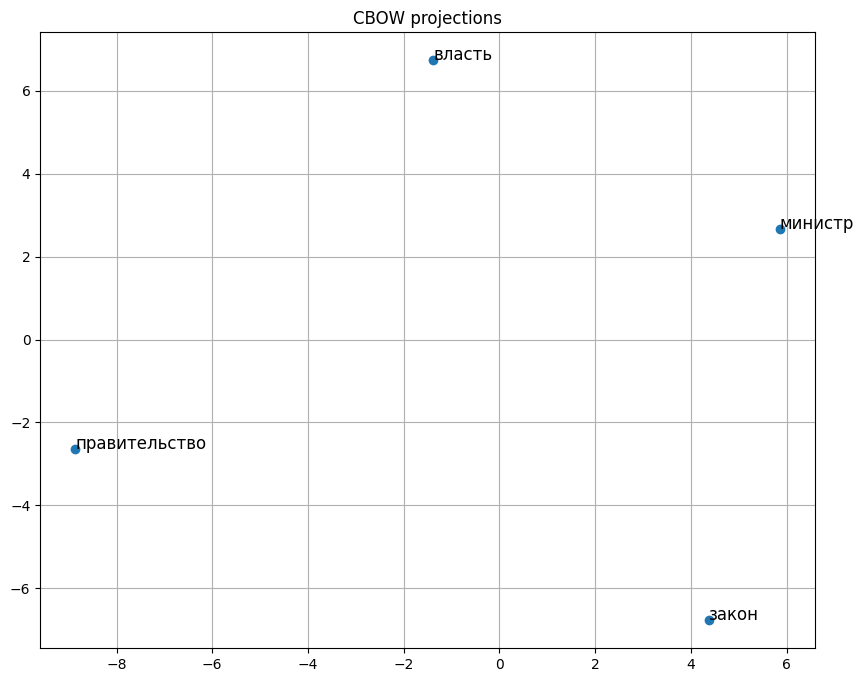

In [110]:
words_to_plot = ["министр", "правительство", "закон", "власть"]

cbow_emb = WordEmbeddings(cbow_model.embeddings.weight.detach().cpu().numpy(), word2id)

print("Попарное косинусное сходство:\n")

for w1, w2 in combinations(words_to_plot, 2):
    if w1 in cbow_emb.word2id and w2 in cbow_emb.word2id:
        id1 = cbow_emb.word2id[w1]
        id2 = cbow_emb.word2id[w2]

        sim = np.dot(cbow_emb.normed_emb[id1], cbow_emb.normed_emb[id2])
        print(f"{w1:>10} — {w2:<10}: {sim:.4f}")
    else:
        print(f"{w1} или {w2} нет в словаре")

print(f"{Fore.RED}Визуализация CBOW эмбеддингов:{Style.RESET_ALL}")
plot_embeddings(cbow_emb, words_to_plot, "CBOW projections")

### Выводы по части 2

- контекст

малый контекст (1) - лучше ловит локальные связи: например, появляются более осмысленные пары вроде «министр — закон» (~0.21) и «правительство - власть» (≈0.20); при увеличении окна (3, 5) сходства становятся слабее и ближе к нулю, а иногда возникают менее очевидные связи вроде «министр — здоровье»

- размерность

50–100 - дают наиболее стабильные результаты: при этих значениях есть различимые связи («правительство — закон» ~0.12-0.13); при 200 качество не выросло - значения сходства часто падают к нулю или становятся отрицательными (например, «министр — власть» < 0), что указывает на шум при недостатке данных

- лучшая модель

context = 1, emb_dim = 50–100 - дает наибольшее количество осмысленных положительных сходств внутри темы (например, «министр — закон», «правительство — власть»), тогда как при большем окне или большей размерности структура становится менее выраженной

- комментарий по визуализациям и косинусу

будто бы визуализации в двумерном пространстве обманчивы и не всегда самый лучший способ толкования качества модели, поэтому я решил добавить косинусное сходство слов. По визуализации не очень ясно качество, только иногда какие-то тематические слова близки